**Header**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
print(f"✓ TensorFlow: {tf.__version__}")
print(f"✓ GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

BASE    = '/content/drive/MyDrive/churn_project/'
PROC    = BASE + 'data/processed/'
RESULTS = BASE + 'results/'

Mounted at /content/drive
✓ TensorFlow: 2.20.0
✓ GPU available: True


**Load preprocessed data:**

In [2]:
import pickle

# Load corrected preprocessed data
with open(PROC + 'final_data.pkl', 'rb') as f:
    final_data = pickle.load(f)

datasets = ['Insurance', 'ISP', 'Telecom']

# Verify shapes and feature counts
print("Data loaded from final_data.pkl:")
for name in datasets:
    print(f"  {name:12} → "
          f"train: {final_data[name]['X_train'].shape}  "
          f"test: {final_data[name]['X_test'].shape}  "
          f"features: {final_data[name]['X_train'].shape[1]}")

print("\nExpected features:")
print("  Insurance  → 16")
print("  ISP        → 9  (id column removed)")
print("  Telecom    → 19")
print("\n✓ Data loaded correctly")

Data loaded from final_data.pkl:
  Insurance    → train: (47905, 16)  test: (11977, 16)  features: 16
  ISP          → train: (64080, 9)  test: (14455, 9)  features: 9
  Telecom      → train: (4556, 19)  test: (667, 19)  features: 19

Expected features:
  Insurance  → 16
  ISP        → 9  (id column removed)
  Telecom    → 19

✓ Data loaded correctly


**Reshape data for CNN input:**

In [3]:
cnn_data = {}

for name in datasets:
    X_train = final_data[name]['X_train'].values
    X_test  = final_data[name]['X_test'].values
    y_train = final_data[name]['y_train'].values
    y_test  = final_data[name]['y_test'].values

    cnn_data[name] = {
        'X_train_3d' : X_train.reshape(
            X_train.shape[0], X_train.shape[1], 1),
        'X_test_3d'  : X_test.reshape(
            X_test.shape[0],  X_test.shape[1],  1),
        'y_train'    : y_train,
        'y_test'     : y_test,
        'n_features' : X_train.shape[1]
    }
    print(f"{name:12} → "
          f"train_3d: {cnn_data[name]['X_train_3d'].shape}  "
          f"test_3d:  {cnn_data[name]['X_test_3d'].shape}")

print("\n✓ Data reshaped for CNN input")

Insurance    → train_3d: (47905, 16, 1)  test_3d:  (11977, 16, 1)
ISP          → train_3d: (64080, 9, 1)  test_3d:  (14455, 9, 1)
Telecom      → train_3d: (4556, 19, 1)  test_3d:  (667, 19, 1)

✓ Data reshaped for CNN input


**Build LFE-CNN(Lightweight Feature Extractor)**

In [4]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D,
                                      Flatten, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def build_LFE_CNN(n_features):
    """
    Figure 5 — LFE-CNN exact architecture:
    Input
    → Conv1D(128, kernel=3, ReLU)
    → Conv1D(128, kernel=3, ReLU)
    → Flatten
    → Dense(64, Tanh)
    → Dense(32, Tanh)
    → Dense(16, Tanh)
    → Dense(1, Sigmoid)
    No MaxPooling, No BatchNorm, No Dropout
    """
    inputs = Input(shape=(n_features, 1))

    # Conv block
    x = Conv1D(filters=128, kernel_size=3,
               activation='relu', padding='same')(inputs)
    x = Conv1D(filters=128, kernel_size=3,
               activation='relu', padding='same')(x)

    # Flatten
    x = Flatten()(x)

    # Dense block — Tanh activation
    x = Dense(64, activation='tanh')(x)
    x = Dense(32, activation='tanh')(x)
    x = Dense(16, activation='tanh')(x)

    # Output
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='LFE_CNN')
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )
    return model

# Verify
sample_lfe = build_LFE_CNN(cnn_data['Insurance']['n_features'])
sample_lfe.summary()
print("\n✓ LFE-CNN built — matches Figure 5 exactly")

Model: "LFE_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 16, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 16, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,553 (717.00 KB)

 Trainable params: 183,553 (717.00 KB)

 Non-trainable params: 0 (0.00 B)


✓ LFE-CNN built — matches Figure 5 exactly


**Build DFE-CNN (Deep Feature Extractor)**

In [5]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D,
                                      Flatten, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
def build_DFE_CNN(n_features):
    """
    Figure 6 — DFE-CNN exact architecture:
    Input
    → Conv1D(512, kernel=3, ReLU)
    → Conv1D(128, kernel=3, ReLU)
    → Conv1D(128, kernel=3, ReLU)
    → Flatten
    → Dense(64, Tanh)
    → Dense(32, Tanh)
    → Dense(16, Tanh)
    → Dense(8, Tanh)       ← extra layer vs LFE-CNN
    → Dense(1, Sigmoid)
    No MaxPooling, No BatchNorm, No Dropout
    """
    inputs = Input(shape=(n_features, 1))

    # Conv block — 3 layers, first has 512 filters
    x = Conv1D(filters=512, kernel_size=3,
               activation='relu', padding='same')(inputs)
    x = Conv1D(filters=128, kernel_size=3,
               activation='relu', padding='same')(x)
    x = Conv1D(filters=128, kernel_size=3,
               activation='relu', padding='same')(x)

    # Flatten
    x = Flatten()(x)

    # Dense block — 4 layers with Tanh
    x = Dense(64, activation='tanh')(x)
    x = Dense(32, activation='tanh')(x)
    x = Dense(16, activation='tanh')(x)
    x = Dense(8,  activation='tanh')(x)

    # Output
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='DFE_CNN')
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = ['accuracy']
    )
    return model

# Verify
sample_dfe = build_DFE_CNN(cnn_data['Insurance']['n_features'])
sample_dfe.summary()
print("\n✓ DFE-CNN built — matches Figure 6 exactly")

Model: "DFE_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 16, 512)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 16, 128)        │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 16, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 381,953 (1.46 MB)

 Trainable params: 381,953 (1.46 MB)

 Non-trainable params: 0 (0.00 B)


✓ DFE-CNN built — matches Figure 6 exactly


**Train LFE-CNN on all 3 datasets**

In [6]:
lfe_models  = {}
lfe_history = {}

callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1
    )
]

for name in datasets:
    print(f"\n{'='*50}")
    print(f"  Training LFE-CNN on {name}")
    print(f"{'='*50}")

    n_features = cnn_data[name]['n_features']
    model      = build_LFE_CNN(n_features)

    history = model.fit(
        cnn_data[name]['X_train_3d'],   # ← fixed
        cnn_data[name]['y_train'],
        epochs          = 50,
        batch_size      = 32,
        validation_data = (cnn_data[name]['X_test_3d'],  # ← fixed
                           cnn_data[name]['y_test']),
        callbacks       = callbacks,
        verbose         = 1
    )

    lfe_models[name]  = model
    lfe_history[name] = history
    print(f"\n✓ {name} LFE-CNN trained")

print("\n✓ All LFE-CNN models trained")


  Training LFE-CNN on Insurance
Epoch 1/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8248 - loss: 0.3954 - val_accuracy: 0.8361 - val_loss: 0.3702
Epoch 2/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8528 - loss: 0.3431 - val_accuracy: 0.8644 - val_loss: 0.3206
Epoch 3/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8722 - loss: 0.3060 - val_accuracy: 0.8859 - val_loss: 0.2915
Epoch 4/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8910 - loss: 0.2700 - val_accuracy: 0.8966 - val_loss: 0.2599
Epoch 5/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9092 - loss: 0.2343 - val_accuracy: 0.9071 - val_loss: 0.2464
Epoch 6/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9238 - loss: 0.2050 - val_accuracy: 0.9186 - val_loss: 0.2221
Epoch 7/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9363 - loss: 0.1786 - val_accuracy: 0.9220 - val_loss: 0.2164
Epoch 8/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - 

**Train DFE-CNN on all 3 datasets**

In [7]:
dfe_models  = {}
dfe_history = {}

callbacks = [
    EarlyStopping(
        monitor              = 'val_loss',
        patience             = 10,
        restore_best_weights = True,
        verbose              = 1
    )
]

for name in datasets:
    print(f"\n{'='*50}")
    print(f"  Training DFE-CNN on {name}")
    print(f"{'='*50}")

    n_features = cnn_data[name]['n_features']
    model      = build_DFE_CNN(n_features)

    history = model.fit(
        cnn_data[name]['X_train_3d'],   # ← fixed
        cnn_data[name]['y_train'],
        epochs          = 50,
        batch_size      = 32,
        validation_data = (cnn_data[name]['X_test_3d'],  # ← fixed
                           cnn_data[name]['y_test']),
        callbacks       = callbacks,
        verbose         = 1
    )

    dfe_models[name]  = model
    dfe_history[name] = history
    print(f"\n✓ {name} DFE-CNN trained")

print("\n✓ All DFE-CNN models trained")


  Training DFE-CNN on Insurance
Epoch 1/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8184 - loss: 0.4105 - val_accuracy: 0.8379 - val_loss: 0.3723
Epoch 2/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8502 - loss: 0.3534 - val_accuracy: 0.8681 - val_loss: 0.3215
Epoch 3/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8692 - loss: 0.3157 - val_accuracy: 0.8708 - val_loss: 0.3156
Epoch 4/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8839 - loss: 0.2883 - val_accuracy: 0.8896 - val_loss: 0.2870
Epoch 5/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8949 - loss: 0.2666 - val_accuracy: 0.8970 - val_loss: 0.2651
Epoch 6/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9036 - loss: 0.2482 - val_accuracy: 0.8970 - val_loss: 0.2674
Epoch 7/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9111 - loss: 0.2329 - val_accuracy: 0.9096 - val_loss: 0.2396
Epoch 8/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - 

**Evaluate both CNNs**

In [8]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              roc_auc_score, cohen_kappa_score,
                              confusion_matrix)

def evaluate_keras_model(name, model, model_name, X_test, y_test):
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob > 0.5).astype(int)

    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, zero_division=0)
    rec   = recall_score(y_test, y_pred, zero_division=0)
    f1    = f1_score(y_test, y_pred, zero_division=0)
    auc   = roc_auc_score(y_test, y_prob)
    kappa = cohen_kappa_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        'Dataset'     : name,
        'Model'       : model_name,
        'Accuracy'    : round(acc   * 100, 2),
        'Precision'   : round(prec  * 100, 2),
        'Recall'      : round(rec   * 100, 2),
        'F1 Score'    : round(f1    * 100, 2),
        'ROC AUC'     : round(auc   * 100, 2),
        'Kappa'       : round(kappa,        4),
        'Specificity' : round(tn/(tn+fp) * 100, 2),
        'True Churn'  : int(tp),
        'False Churn' : int(fp)
    }

cnn_results = []

for name in datasets:
    lfe_res = evaluate_keras_model(
        name, lfe_models[name], 'LFE-CNN',
        cnn_data[name]['X_test_3d'],
        cnn_data[name]['y_test']
    )
    dfe_res = evaluate_keras_model(
        name, dfe_models[name], 'DFE-CNN',
        cnn_data[name]['X_test_3d'],
        cnn_data[name]['y_test']
    )
    cnn_results.extend([lfe_res, dfe_res])

    print(f"\n{name}")
    print(f"  LFE-CNN → Acc: {lfe_res['Accuracy']}%  "
          f"F1: {lfe_res['F1 Score']}%  AUC: {lfe_res['ROC AUC']}%"
    )
    print(f"  DFE-CNN → Acc: {dfe_res['Accuracy']}%  "
          f"F1: {dfe_res['F1 Score']}%  AUC: {dfe_res['ROC AUC']}%"
    )

cnn_results_df = pd.DataFrame(cnn_results)
display(cnn_results_df)



Insurance
  LFE-CNN → Acc: 94.56%  F1: 94.74%  AUC: 97.42%
  DFE-CNN → Acc: 92.67%  F1: 92.89%  AUC: 96.48%

ISP
  LFE-CNN → Acc: 91.12%  F1: 91.95%  AUC: 95.73%
  DFE-CNN → Acc: 93.12%  F1: 93.73%  AUC: 97.49%

Telecom
  LFE-CNN → Acc: 76.01%  F1: 50.31%  AUC: 83.49%
  DFE-CNN → Acc: 83.06%  F1: 58.3%  AUC: 85.85%


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Kappa,Specificity,True Churn,False Churn
0,Insurance,LFE-CNN,94.56,91.62,98.08,94.74,97.42,0.8911,91.03,5873,537
1,Insurance,DFE-CNN,92.67,90.21,95.72,92.89,96.48,0.8534,89.61,5732,622
2,ISP,LFE-CNN,91.12,92.46,91.44,91.95,95.73,0.8206,90.74,7324,597
3,ISP,DFE-CNN,93.12,94.66,92.81,93.73,97.49,0.8610,93.50,7434,419
4,Telecom,LFE-CNN,76.01,35.68,85.26,50.31,83.49,0.3782,74.48,81,146
5,Telecom,DFE-CNN,83.06,44.89,83.16,58.30,85.85,0.4884,83.04,79,97


**Plot training history**

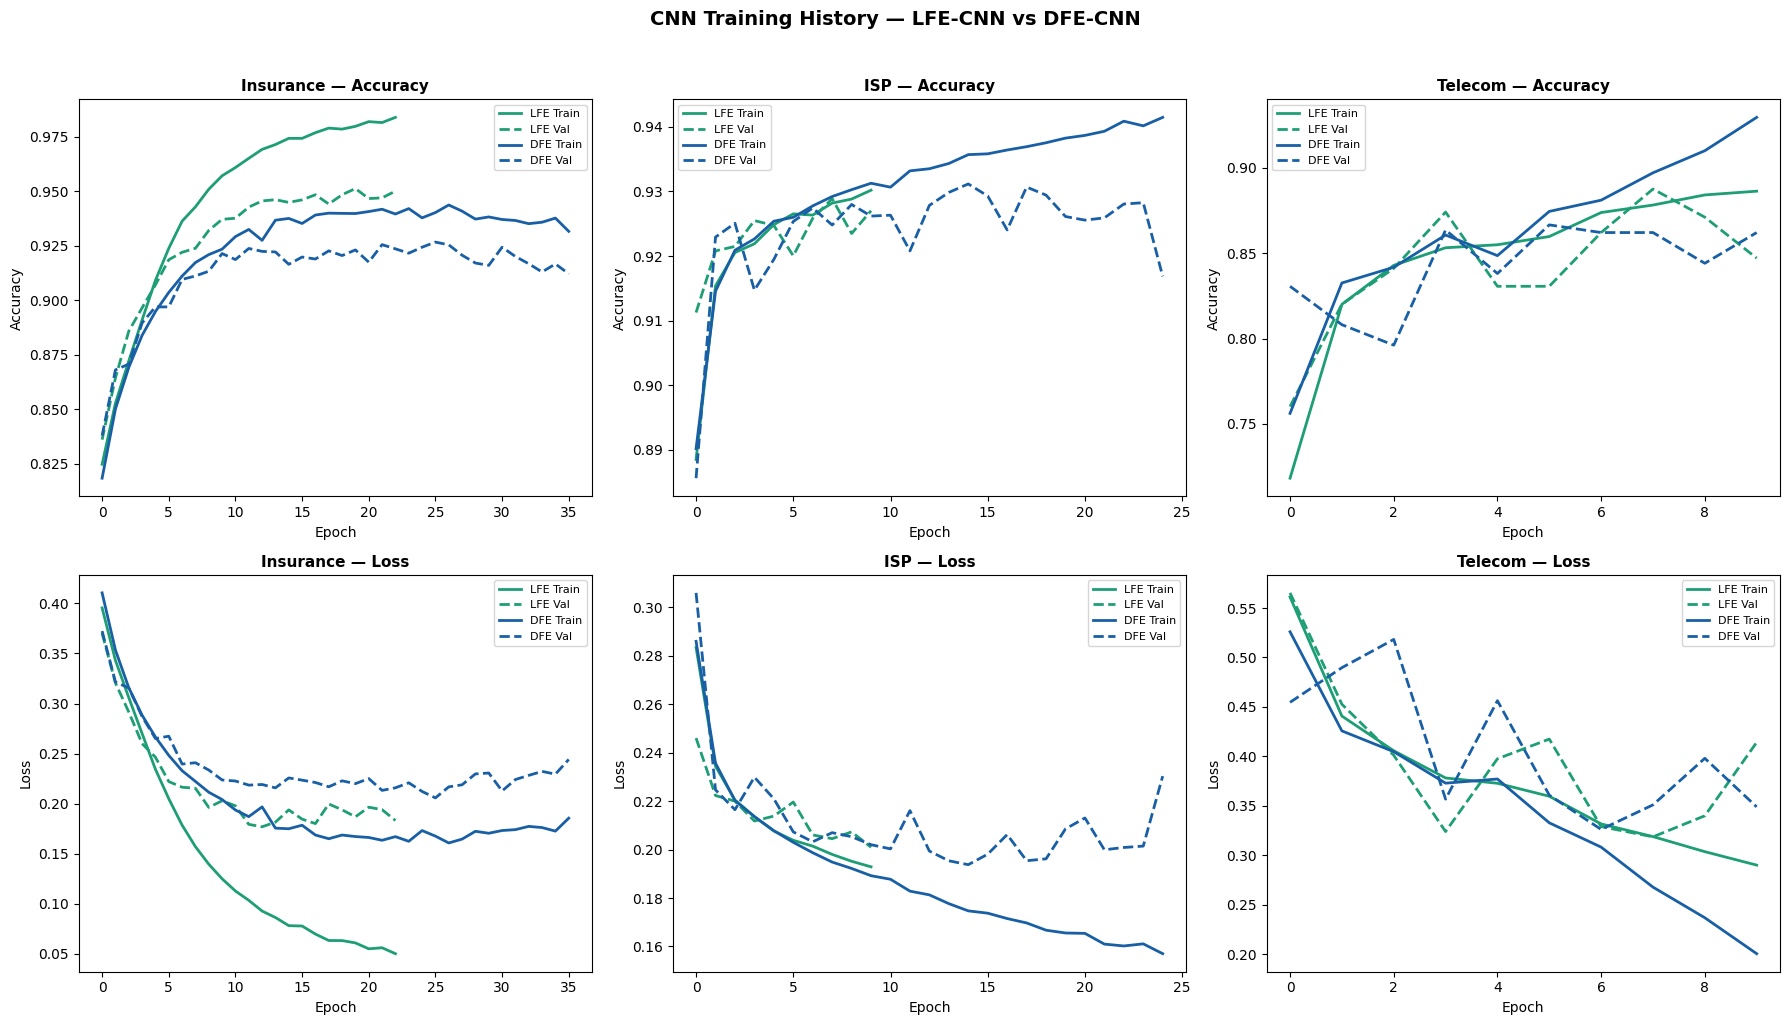

✓ Saved training history plots


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, name in enumerate(datasets):
    # Accuracy
    axes[0, col].plot(lfe_history[name].history['accuracy'],
                      label='LFE Train', color='#1D9E75', linewidth=2)
    axes[0, col].plot(lfe_history[name].history['val_accuracy'],
                      label='LFE Val',   color='#1D9E75',
                      linewidth=2, linestyle='--')
    axes[0, col].plot(dfe_history[name].history['accuracy'],
                      label='DFE Train', color='#185FA5', linewidth=2)
    axes[0, col].plot(dfe_history[name].history['val_accuracy'],
                      label='DFE Val',   color='#185FA5',
                      linewidth=2, linestyle='--')
    axes[0, col].set_title(f'{name} — Accuracy',
                            fontweight='bold', fontsize=11)
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Accuracy')
    axes[0, col].legend(fontsize=8)

    # Loss
    axes[1, col].plot(lfe_history[name].history['loss'],
                      label='LFE Train', color='#1D9E75', linewidth=2)
    axes[1, col].plot(lfe_history[name].history['val_loss'],
                      label='LFE Val',   color='#1D9E75',
                      linewidth=2, linestyle='--')
    axes[1, col].plot(dfe_history[name].history['loss'],
                      label='DFE Train', color='#185FA5', linewidth=2)
    axes[1, col].plot(dfe_history[name].history['val_loss'],
                      label='DFE Val',   color='#185FA5',
                      linewidth=2, linestyle='--')
    axes[1, col].set_title(f'{name} — Loss',
                            fontweight='bold', fontsize=11)
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Loss')
    axes[1, col].legend(fontsize=8)

plt.suptitle('CNN Training History — LFE-CNN vs DFE-CNN',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS + 'cnn_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved training history plots")

**Save CNN models and results**

In [10]:
# Cell 6 — Save both CNN models
import os
import pickle

expected_features = {
    'Insurance': 16,
    'ISP'      : 9,
    'Telecom'  : 19
}

# ── Save and verify LFE models ────────────────────────────
lfe_path = PROC + 'lfe_models.pkl'
with open(lfe_path, 'wb') as f:
    pickle.dump(lfe_models, f)

size = os.path.getsize(lfe_path) / 1024 / 1024
print(f"✓ lfe_models.pkl saved → {lfe_path}")
print(f"  File size: {size:.1f} MB")
print("\nVerifying LFE input shapes:")

with open(lfe_path, 'rb') as f:
    verify_lfe = pickle.load(f)

lfe_correct = True
for name in ['Insurance', 'ISP', 'Telecom']:
    actual   = verify_lfe[name].input_shape[1]
    expected = expected_features[name]
    status   = '✅' if actual == expected else '❌'
    print(f"  {name:12} → features: {actual}  "
          f"expected: {expected}  {status}")
    if actual != expected:
        lfe_correct = False

# ── Save and verify DFE models ────────────────────────────
print()
dfe_path = PROC + 'dfe_models.pkl'
with open(dfe_path, 'wb') as f:
    pickle.dump(dfe_models, f)

size = os.path.getsize(dfe_path) / 1024 / 1024
print(f"✓ dfe_models.pkl saved → {dfe_path}")
print(f"  File size: {size:.1f} MB")
print("\nVerifying DFE input shapes:")

with open(dfe_path, 'rb') as f:
    verify_dfe = pickle.load(f)

dfe_correct = True
for name in ['Insurance', 'ISP', 'Telecom']:
    actual   = verify_dfe[name].input_shape[1]
    expected = expected_features[name]
    status   = '✅' if actual == expected else '❌'
    print(f"  {name:12} → features: {actual}  "
          f"expected: {expected}  {status}")
    if actual != expected:
        dfe_correct = False

# ── Final status ──────────────────────────────────────────
print()
if lfe_correct and dfe_correct:
    print("✅ Both models saved correctly")
    print("✅ Safe to run 05_ensemble.ipynb now")
else:
    print("❌ Shape mismatch found — do not proceed")
    print("   Check which model failed and retrain")

✓ lfe_models.pkl saved → /content/drive/MyDrive/churn_project/data/processed/lfe_models.pkl
  File size: 6.1 MB

Verifying LFE input shapes:
  Insurance    → features: 16  expected: 16  ✅
  ISP          → features: 9  expected: 9  ✅
  Telecom      → features: 19  expected: 19  ✅

✓ dfe_models.pkl saved → /content/drive/MyDrive/churn_project/data/processed/dfe_models.pkl
  File size: 12.9 MB

Verifying DFE input shapes:
  Insurance    → features: 16  expected: 16  ✅
  ISP          → features: 9  expected: 9  ✅
  Telecom      → features: 19  expected: 19  ✅

✅ Both models saved correctly
✅ Safe to run 05_ensemble.ipynb now
